
El roadmap es el siguiente:

0. Se establece el baseline de 5 s y 1 fps
1. Comparar facial cropping vs original
2. Aumentar sampling a 2 y 5 fps, manteniendo 5 s de ventana
3. Aumentar tamaño de ventana a 10 y 15 segundos (si el hardware lo permite).
4. Probar prompts con distintos enfoques. Detección pura, otorgar un baseline como referencia.

In [1]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
import re

In [2]:
def get_eval_per_subject_act_df(res, gt):
    '''
    Al ser las predicciones por ventana, se realiza una agregacion por sujeto y actividad
    para poder compararlas con las etiquetas GT.
    '''
    df_predicted_mean = (
        res.query("binary_stress != -1")
        .groupby(['subject', 'activity'], as_index=False)['binary_stress']
        .sum()
        .assign(
            binary_stress = lambda x: (x['binary_stress'] >= 1).astype(int),
            subject_activity=lambda x: x['subject'].astype(str) + '_' + x['activity'].astype(str))
    )[['subject_activity', 'binary_stress']]

    eval_df = pd.merge(
        gt.rename(columns={'subject/task' : 'subject_activity', 'binary-stress': 'y_true'}),
        df_predicted_mean.rename(columns={'binary_stress': 'y_pred'}),
        on='subject_activity',
        how='inner'
    )

    return eval_df

def print_results(res, gt, title = 'Stress Prediction per subject and activity'):

    eval_df = get_eval_per_subject_act_df(res, gt)

    print(classification_report(eval_df['y_true'], eval_df['y_pred']))
    cm = confusion_matrix(eval_df['y_true'], eval_df['y_pred'])

    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm, 
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['No Stress (0)', 'Stress (1)'], 
        yticklabels=['No Stress (0)', 'Stress (1)'],
        cbar=False
    )

    plt.title(title)
    plt.ylabel('Actual Label (GT)')
    plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

In [3]:
gt = pd.read_csv('../data/labels_v2.csv', sep = ';')[['subject/task', 'binary-stress']]

# Original VS cropping:

              precision    recall  f1-score   support

           0       1.00      0.01      0.02       266
           1       0.54      1.00      0.70       312

    accuracy                           0.54       578
   macro avg       0.77      0.51      0.36       578
weighted avg       0.75      0.54      0.39       578



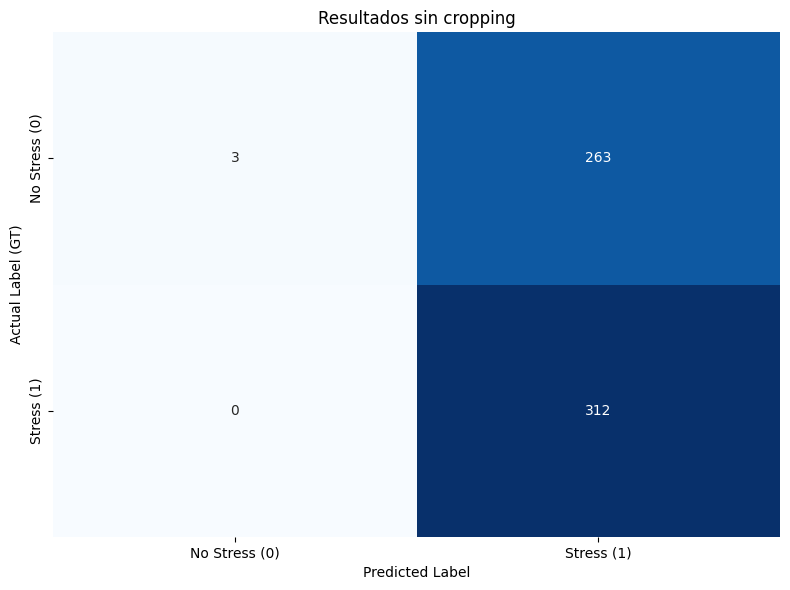

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       266
           1       0.54      1.00      0.70       312

    accuracy                           0.54       578
   macro avg       0.27      0.50      0.35       578
weighted avg       0.29      0.54      0.38       578



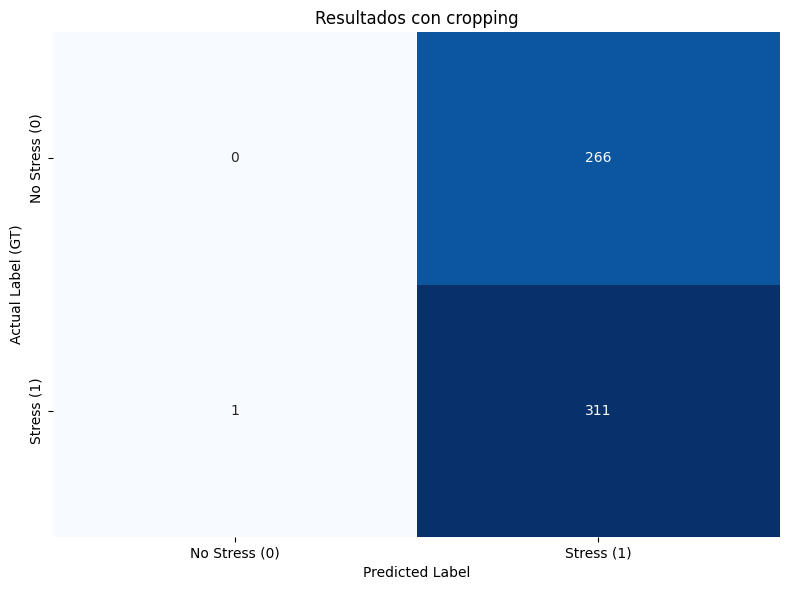

In [6]:
no_cropping = pd.read_csv('../results/Qwen3_VL_2B_Instruct_5s1fps_results.csv')
cropping = pd.read_csv('../results/Qwen3_VL_2B_Instruct_5s1fps_cropped_results.csv')

print_results(no_cropping, gt, title='Resultados sin cropping')
print_results(cropping, gt, title='Resultados con cropping')

Los resultados son penosos en ambos casos, ligeramente mejor sin cropping. Pero por eficiencia computacional, vamos a continuar con el experimento con cropping.

# Aumentar FPS manteniendo ventana de 5s:

In [7]:
df_5s1fps = pd.read_csv('../results/Qwen3_VL_4B_Instruct_5s1fps_cropped_results.csv')
df_5s2fps = pd.read_csv('../results/Qwen3_VL_4B_Instruct_5s2fps_cropped_results.csv')
df_5s5fps = pd.read_csv('../results/Qwen3_VL_4B_Instruct_5s5fps_cropped_results.csv')

              precision    recall  f1-score   support

           0       0.48      0.96      0.64       266
           1       0.78      0.11      0.20       312

    accuracy                           0.50       578
   macro avg       0.63      0.54      0.42       578
weighted avg       0.64      0.50      0.40       578



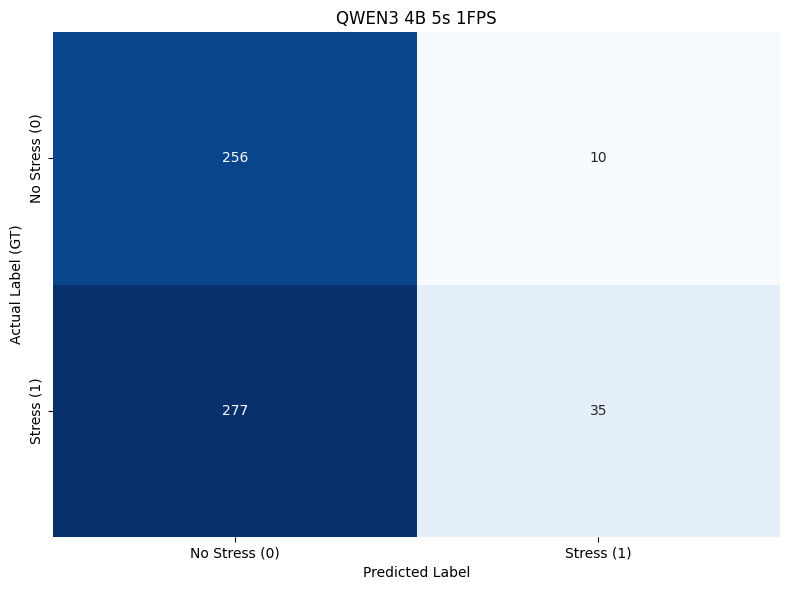

In [8]:
print_results(df_5s1fps, gt, title='QWEN3 4B 5s 1FPS')

              precision    recall  f1-score   support

           0       0.48      0.95      0.64       266
           1       0.77      0.14      0.23       312

    accuracy                           0.51       578
   macro avg       0.63      0.54      0.44       578
weighted avg       0.64      0.51      0.42       578



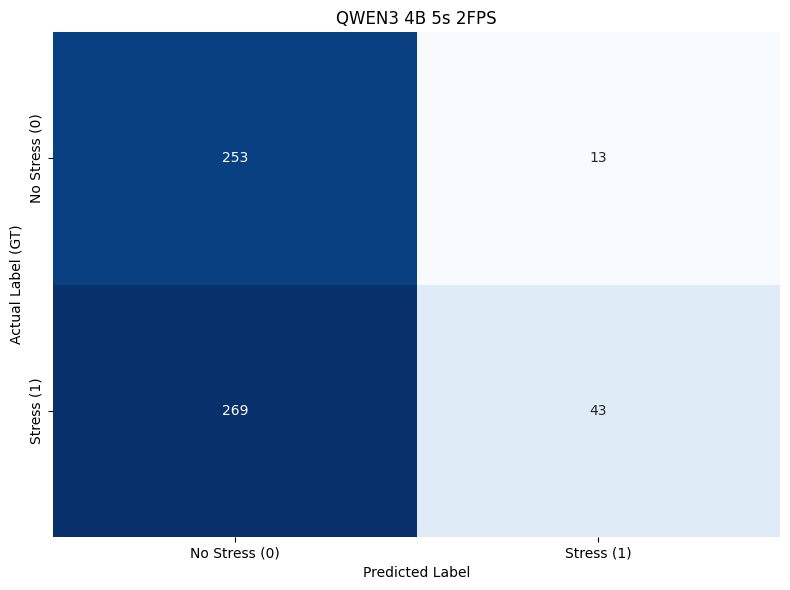

In [9]:
print_results(df_5s2fps, gt, title='QWEN3 4B 5s 2FPS')

              precision    recall  f1-score   support

           0       0.49      0.94      0.64       266
           1       0.75      0.15      0.26       312

    accuracy                           0.52       578
   macro avg       0.62      0.55      0.45       578
weighted avg       0.63      0.52      0.43       578



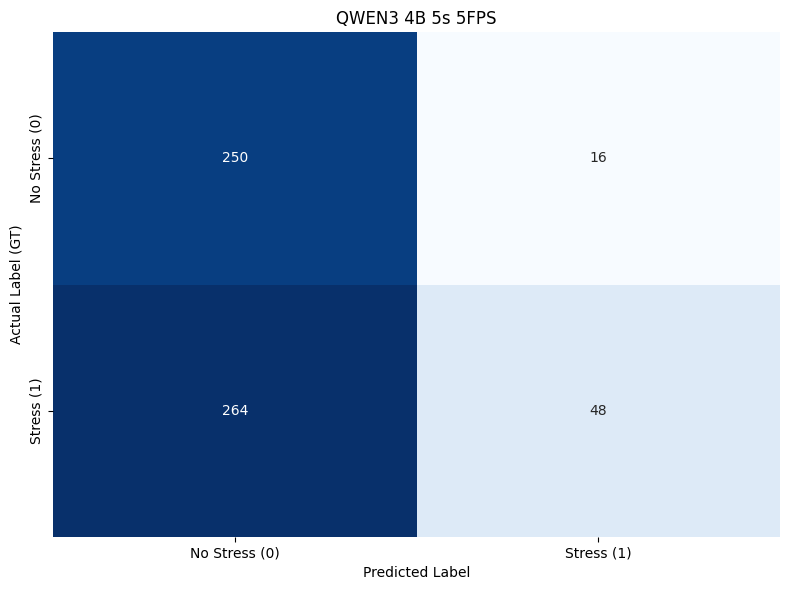

In [10]:
print_results(df_5s5fps, gt, title='QWEN3 4B 5s 5FPS')

              precision    recall  f1-score   support

           0       0.48      0.95      0.64       266
           1       0.75      0.13      0.22       312

    accuracy                           0.51       578
   macro avg       0.62      0.54      0.43       578
weighted avg       0.63      0.51      0.41       578



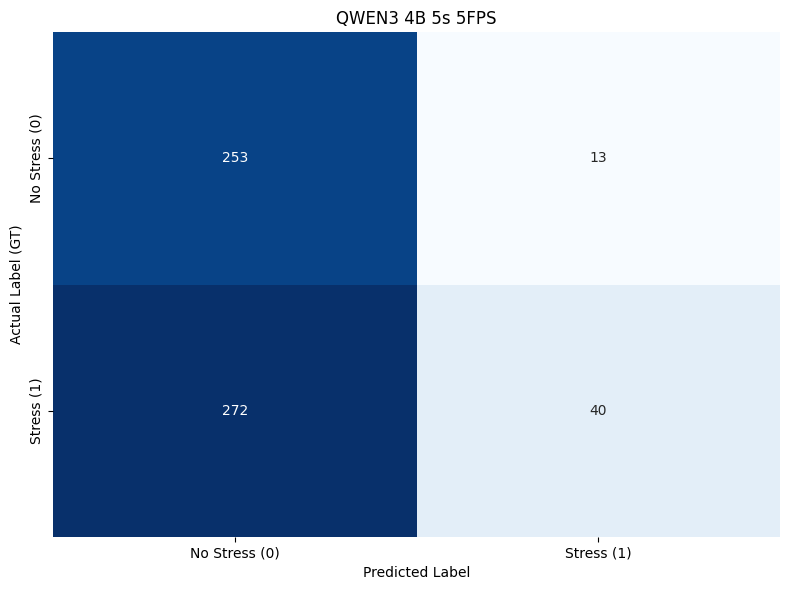

In [11]:
df_10s5fps = pd.read_csv('../results/Qwen3_VL_4B_Instruct_10s5fps_cropped_results.csv')
print_results(df_10s5fps, gt, title='QWEN3 4B 5s 5FPS')

              precision    recall  f1-score   support

           0       0.48      0.97      0.64       266
           1       0.79      0.10      0.17       312

    accuracy                           0.50       578
   macro avg       0.63      0.53      0.41       578
weighted avg       0.65      0.50      0.39       578



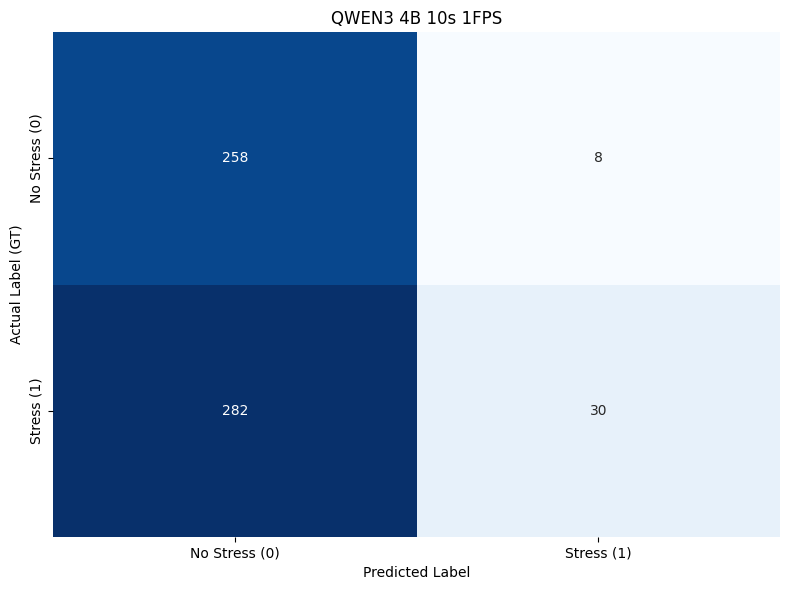

In [5]:
df_10s1fps = pd.read_csv('../results/Qwen3_VL_4B_Instruct_10s1fps_cropped_results.csv')
print_results(df_10s1fps, gt, title='QWEN3 4B 10s 1FPS')

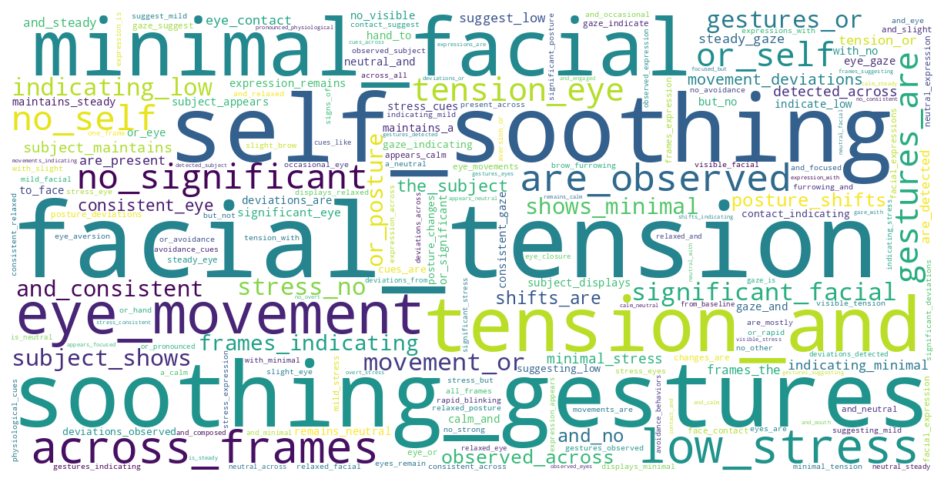

In [ ]:
def bigram_wordcloud(df, col, min_count=2, max_words=200, stopwords=False):
    texts = df[col].dropna().astype(str).str.lower()

    tokens = []
    for t in texts:
        t = re.sub(r"[^\w\s]", " ", t)
        words = t.split()
        tokens.extend(zip(words, words[1:]))

    bigram_counts = Counter(tokens)
    bigram_counts = {
        f"{w1}_{w2}": c
        for (w1, w2), c in bigram_counts.items() if c >= min_count
    }

    wc = WordCloud(width=1200, height=600, background_color="white")
    wc.generate_from_frequencies(bigram_counts)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

bigram_wordcloud(df_10s1fps, "reasoning")

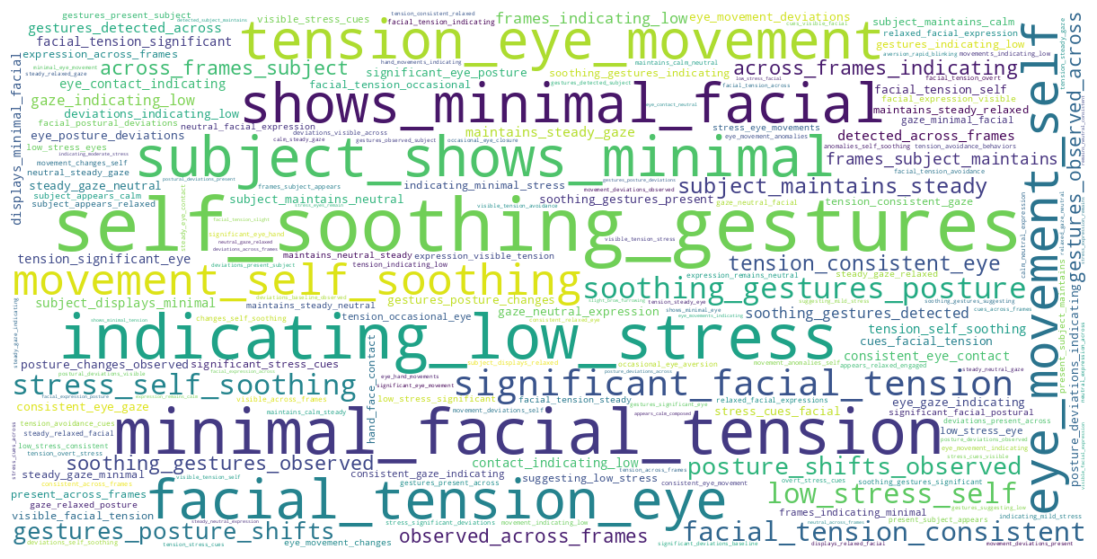

In [ ]:
def trigram_wordcloud(df, col, min_count=2, max_words=200):
    texts = df[col].dropna().astype(str).str.lower()
    stopwords = set(STOPWORDS)

    trigrams = []

    for t in texts:
        t = re.sub(r"[^\w\s]", " ", t)
        words = [w for w in t.split() if w not in stopwords and len(w) > 2]

        trigrams.extend(zip(words, words[0+1:], words[0+2:]))

    trigram_counts = Counter(trigrams)
    trigram_counts = {
        f"{w1}_{w2}_{w3}": c
        for (w1, w2, w3), c in trigram_counts.items() if c >= min_count
    }

    wc = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        max_words=max_words
    ).generate_from_frequencies(trigram_counts)

    plt.figure(figsize=(14, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

trigram_wordcloud(df_10s5fps, "reasoning")

In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import pandas as pd

texts = df_10s5fps["reasoning"].dropna().astype(str)

vec = TfidfVectorizer(stop_words="english", max_df=0.9, min_df=3)
X = vec.fit_transform(texts)

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

clustered = pd.DataFrame({"text": texts.values, "cluster": labels})

In [43]:
for c in sorted(clustered["cluster"].unique()):
    print(f"\n===== CLUSTER {c} =====")
    examples = clustered.loc[clustered["cluster"] == c, "text"].head(5)
    for t in examples:
        print("-", t[:300].replace("\n", " "))


===== CLUSTER 0 =====
- Subject displays minimal facial tension and consistent eye contact, indicating low stress. No significant deviations from baseline observed.
- Subject shows minimal facial tension and no significant eye or posture deviations, indicating low stress.
- The subject displays minimal facial tension and no significant eye or posture deviations, indicating low stress. Facial expression remains neutral across frames.
- Subject maintains steady gaze and minimal facial tension across frames, indicating low stress. No significant deviations from baseline observed.
- Subject maintains steady gaze and minimal facial tension across frames, indicating low stress. No self-soothing gestures or significant eye/face deviations are observed.

===== CLUSTER 1 =====
- No significant facial tension, eye movement, or self-soothing gestures are observed across frames. The subject maintains steady, relaxed eye contact and neutral expression.
- No visible stress cues such as facial tensi